In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
boardgames = pd.read_csv('BoardGameName.csv') ##טבלת הליבה
prices = pd.read_csv('BoardGamePrice.csv')
creators = pd.read_csv('CreatorName.csv')
expansions = pd.read_csv('ExpansionName.csv')
playstyle = pd.read_csv('PlayStyle.csv')
release_year = pd.read_csv('ReleaseYear.csv')

In [7]:
boardgames.head(3) ##שם משחק הקופסה

,BoardGameID,BoardGameName,ReleaseYear,PrimaryMechanic,PlayerCountMin,PlayerCountMax,PlayTimeMin,PlayTimeMax,ComplexityLevel
0,1,Everdell,2018,Worker Placement,1,4,40,120,2.8
1,2,Tapestry,2019,Civilization Building,1,5,90,120,2.9
2,3,Wonderland's War,2022,Bag Building,2,5,45,150,3.0


In [8]:
prices.head(3)##מחירים של המשחקים

,BoardGameID,BoardGameName,Origin Price,Selling Price,Price Today,Hand
0,1,Everdell,1200,1000,1000,1
1,2,Tapestry,650,550,800,1
2,3,Wonderland's War,550,450,700,1


In [13]:
creators.head(3) ##יוצרי המשחקים

,CreatorID,CreatorName,Role,BoardGameID
0,1,James A. Wilson,Designer,1
1,2,Andrew Bosley,Artist,1
2,3,Starling Games,Publisher,1


In [10]:
expansions.head(3) ##הרחבות למשחקים

,ExpansionID,BoardGameID,ExpansionName,ReleaseYear
0,1,1,Pearlbrook,2019
1,2,1,Spirecrest,2020
2,3,1,Bellfaire,2020


In [11]:
playstyle.head(3) ##סגנונות משחק

,PlayStyleID,PrimaryMechanic,GameTheme,BoardGameID
0,1,Worker Placement,Forest / City-Building,1
1,2,Civilization Building,Strategy / City-Building,2
2,3,Bag Building,Fantasy / Area Control,3


In [12]:
release_year.head(3) ##תאריך יציאה לאור

,ReleaseID,BoardGameID,ReleaseYear
0,1,1,2018
1,2,2,2019
2,3,3,2022


In [33]:
print(expansions.head())
print(expansions.columns)

   ExpansionID  BoardGameID ExpansionName  ReleaseYear
0            1            1    Pearlbrook         2019
1            2            1    Spirecrest         2020
2            3            1     Bellfaire         2020
3            4            1      New Leaf         2022
4            5            1      Mistwood         2022
Index(['ExpansionID', 'BoardGameID', 'ExpansionName', 'ReleaseYear'], dtype='object')


In [35]:
expansions_per_game = (
    expansions
    .groupby("BoardGameID")["ExpansionID"]
    .count()
    .reset_index(name="NumExpansions")
)
print(expansions_per_game)

    BoardGameID  NumExpansions
0             1              5
1             2              4
2             3              1
3             4              1
4             6              1
5             8              1
6            11              1
7            12              1
8            13              2
9            14              2
10           15              3
11           16              5
12           20              3
13           21              3
14           22              1
15           23              1


In [36]:
expansions_per_game2 = expansions_per_game.merge(
    boardgames[["BoardGameID", "BoardGameName"]],
    on="BoardGameID",
    how="left"
)

In [37]:
print(expansions_per_game2)

    BoardGameID  NumExpansions              BoardGameName
0             1              5                   Everdell
1             2              4                   Tapestry
2             3              1           Wonderland's War
3             4              1            Critter Kitchen
4             6              1       Dice Throne Season 2
5             8              1          Dice Throne X-Men
6            11              1        Lost Ruins of Arnak
7            12              1                 Dice Forge
8            13              2              Marvel United
9            14              2       Marvel United: X-Men
10           15              3  Marvel United: Multiverse
11           16              5           Marvel Champions
12           20              3     Dwellings of Eldervale
13           21              3                     Clank!
14           22              1                     Canvas
15           23              1             7 Wonders Duel


In [38]:
expansions_per_game2 = expansions_per_game2[
    ["BoardGameID", "BoardGameName", "NumExpansions"]
]


In [86]:
expansions_per_game2.head(6)

,BoardGameID,BoardGameName,NumExpansions
0,1,Everdell,5
1,2,Tapestry,4
2,3,Wonderland's War,1
3,4,Critter Kitchen,1
4,6,Dice Throne Season 2,1
5,8,Dice Throne X-Men,1


In [43]:
games_merged = (
    boardgames
    .merge(prices[["BoardGameID", "Origin Price", "Selling Price", "Price Today"]], on="BoardGameID", how="left")
    .merge(playstyle[["BoardGameID", "GameTheme"]], on="BoardGameID", how="left")
    .merge(expansions_per_game, on="BoardGameID", how="left")
)

In [46]:
games_merged.head(3)

,BoardGameID,BoardGameName,ReleaseYear,PrimaryMechanic,PlayerCountMin,PlayerCountMax,PlayTimeMin,PlayTimeMax,ComplexityLevel,Origin Price,Selling Price,Price Today,GameTheme,NumExpansions
0,1,Everdell,2018,Worker Placement,1,4,40,120,2.8,1200,1000,1000,Forest / City-Building,5.0
1,2,Tapestry,2019,Civilization Building,1,5,90,120,2.9,650,550,800,Strategy / City-Building,4.0
2,3,Wonderland's War,2022,Bag Building,2,5,45,150,3.0,550,450,700,Fantasy / Area Control,1.0


In [48]:
print(games_merged)

    BoardGameID                 BoardGameName  ReleaseYear  \
0             1                      Everdell         2018   
1             2                      Tapestry         2019   
2             3              Wonderland's War         2022   
3             4               Critter Kitchen         2025   
4             5                  Grimm Forest         2018   
5             6          Dice Throne Season 2         2019   
6             7            Dice Throne Marvel         2021   
7             8             Dice Throne X-Men         2024   
8             9  Dice Throne Santa vs Krampus         2021   
9            10          Dice Throne Deadpool         2022   
10           11           Lost Ruins of Arnak         2020   
11           12                    Dice Forge         2017   
12           13                 Marvel United         2020   
13           14          Marvel United: X-Men         2022   
14           15     Marvel United: Multiverse         2023   
15      

In [49]:
games_merged["NumExpansions"] = games_merged["NumExpansions"].fillna(0).astype(int)

In [50]:
print(games_merged)

    BoardGameID                 BoardGameName  ReleaseYear  \
0             1                      Everdell         2018   
1             2                      Tapestry         2019   
2             3              Wonderland's War         2022   
3             4               Critter Kitchen         2025   
4             5                  Grimm Forest         2018   
5             6          Dice Throne Season 2         2019   
6             7            Dice Throne Marvel         2021   
7             8             Dice Throne X-Men         2024   
8             9  Dice Throne Santa vs Krampus         2021   
9            10          Dice Throne Deadpool         2022   
10           11           Lost Ruins of Arnak         2020   
11           12                    Dice Forge         2017   
12           13                 Marvel United         2020   
13           14          Marvel United: X-Men         2022   
14           15     Marvel United: Multiverse         2023   
15      

In [51]:
games_merged["Profit_vs_Origin"] = games_merged["Selling Price"] - games_merged["Origin Price"]
games_merged["Delta_Today_vs_Origin"] = games_merged["Price Today"] - games_merged["Origin Price"]

In [52]:
games_merged.head(3)

,BoardGameID,BoardGameName,ReleaseYear,PrimaryMechanic,PlayerCountMin,PlayerCountMax,PlayTimeMin,PlayTimeMax,ComplexityLevel,Origin Price,Selling Price,Price Today,GameTheme,NumExpansions,Profit_vs_Origin,Delta_Today_vs_Origin
0,1,Everdell,2018,Worker Placement,1,4,40,120,2.8,1200,1000,1000,Forest / City-Building,5,-200,-200
1,2,Tapestry,2019,Civilization Building,1,5,90,120,2.9,650,550,800,Strategy / City-Building,4,-100,150
2,3,Wonderland's War,2022,Bag Building,2,5,45,150,3.0,550,450,700,Fantasy / Area Control,1,-100,150


In [53]:
price_analysis = games_merged[
    [
        "BoardGameID",
        "BoardGameName",
        "Origin Price",
        "Selling Price",
        "Price Today",
        "Profit_vs_Origin",
        "Delta_Today_vs_Origin"
    ]
]

In [54]:
price_analysis.head()


,BoardGameID,BoardGameName,Origin Price,Selling Price,Price Today,Profit_vs_Origin,Delta_Today_vs_Origin
0,1,Everdell,1200,1000,1000,-200,-200
1,2,Tapestry,650,550,800,-100,150
2,3,Wonderland's War,550,450,700,-100,150
3,4,Critter Kitchen,450,400,600,-50,150
4,5,Grimm Forest,200,180,180,-20,-20


In [55]:
price_analysis = games_merged[
    [
        "BoardGameID",
        "BoardGameName",
        "Origin Price",
        "Selling Price",
        "Price Today",
        "Profit_vs_Origin",
        "Delta_Today_vs_Origin"
    ]
]

In [56]:
print(price_analysis)

    BoardGameID                 BoardGameName  Origin Price  Selling Price  \
0             1                      Everdell          1200           1000   
1             2                      Tapestry           650            550   
2             3              Wonderland's War           550            450   
3             4               Critter Kitchen           450            400   
4             5                  Grimm Forest           200            180   
5             6          Dice Throne Season 2           450            380   
6             7            Dice Throne Marvel           800            800   
7             8             Dice Throne X-Men           800            800   
8             9  Dice Throne Santa vs Krampus           200            140   
9            10          Dice Throne Deadpool           110            140   
10           11           Lost Ruins of Arnak           220            200   
11           12                    Dice Forge           320     

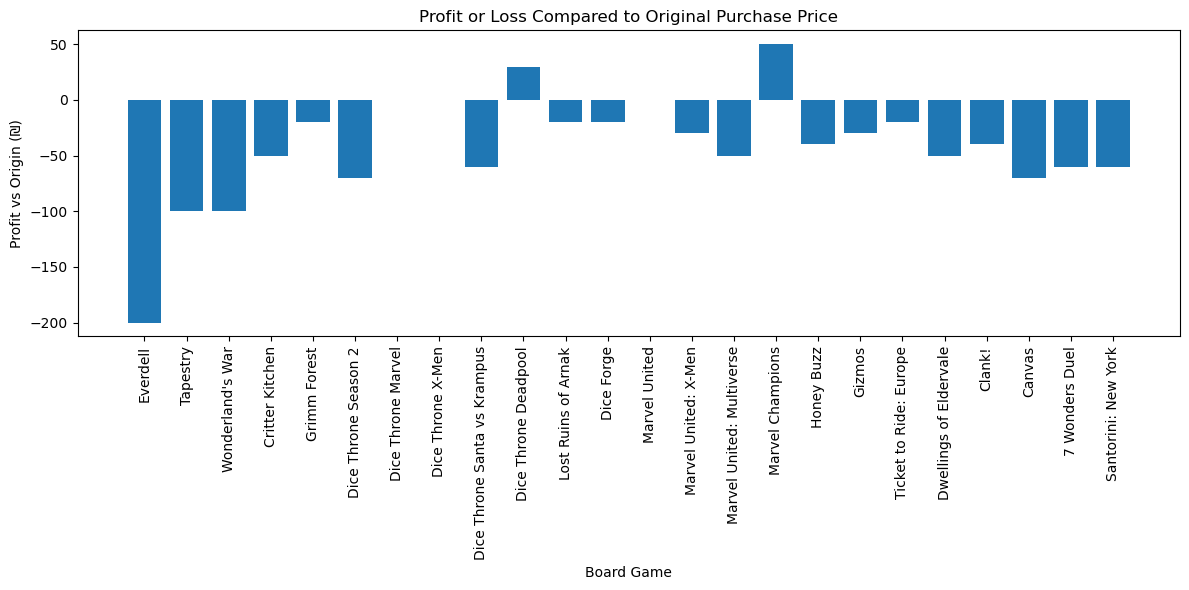

In [65]:
plt.figure(figsize=(12, 6))
plt.bar(
    price_analysis["BoardGameName"],
    price_analysis["Profit_vs_Origin"])
plt.xticks(rotation=90)
plt.xlabel("Board Game")
plt.ylabel("Profit vs Origin (₪)")
plt.title("Profit or Loss Compared to Original Purchase Price")

plt.tight_layout()
plt.show() ## ממה שרואים המשחקים MARVEL CHAMPIONS + DiceThrone DP שווים היום יותר ממה שנקנו
## המשחקים Marvel Dice Throne/ DiceThrone Xmen/ Marvel United שווים היום באותו המחיר בו נקנו.
## המשחק ששווה הכי פחות ביחס להשקעה הוא Everdell ששוויו הוא 200 ש"ח פחות

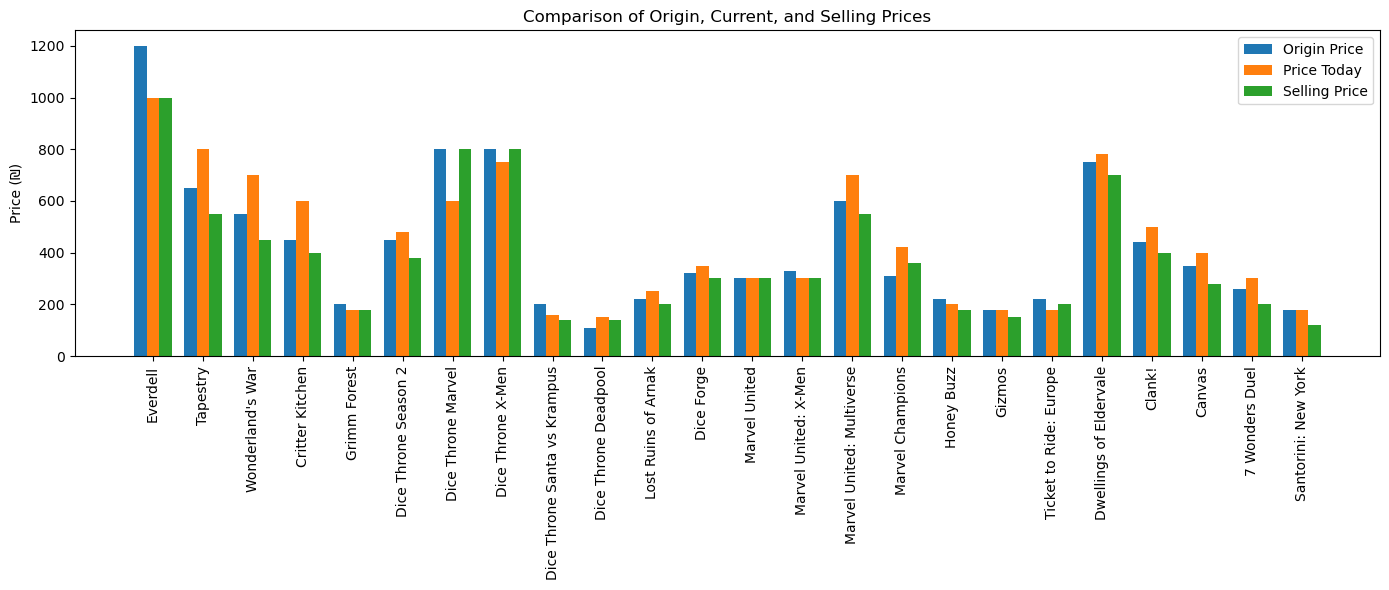

In [75]:
import numpy as np

games = price_analysis["BoardGameName"]
origin = price_analysis["Origin Price"]
today = price_analysis["Price Today"]
selling = price_analysis["Selling Price"]

x = np.arange(len(games)) 
width = 0.25

plt.figure(figsize=(14, 6))

# כאן אוסיף 3 עמודות לכל משחק כדי שנראה את הפער בצורה יותר מובהקת
plt.bar(x - width, origin, width, label="Origin Price")
plt.bar(x, today, width, label="Price Today")
plt.bar(x + width, selling, width, label="Selling Price")

plt.xticks(x, games, rotation=90)
plt.ylabel("Price (₪)")
plt.title("Comparison of Origin, Current, and Selling Prices")

plt.legend()
plt.tight_layout()
plt.show()


## כרגע אפשר לראות את המשחקים היקרים ביותר, מה מהם קרוב יחסית לעלותם היום ומה שווי המכירה שלהם כרגע מהאוסף הקיים
## ניתן לראות גם שיש משחקים שעלותם היום גבוהה יותר מהעלות בה נרכשו בעבר

In [67]:
##כרגע אנסה להגיע לגרף חדש שמציג את רמת המורכבות של משחק לעומת משך הזמן שלו
games_depth = games_merged[[
    "BoardGameName",
    "PlayTimeMin",
    "PlayTimeMax",
    "ComplexityLevel"
]].copy()

## חישוב ממוצע של המשחקים
games_depth["AvgPlayTime"] = (games_depth["PlayTimeMin"] + games_depth["PlayTimeMax"]) / 2


In [68]:
games_depth.head(10)

,BoardGameName,PlayTimeMin,PlayTimeMax,ComplexityLevel,AvgPlayTime
0,Everdell,40,120,2.8,80.0
1,Tapestry,90,120,2.9,105.0
2,Wonderland's War,45,150,3.0,97.5
3,Critter Kitchen,45,90,2.5,67.5
4,Grimm Forest,45,60,2.0,52.5
5,Dice Throne Season 2,20,40,2.3,30.0
6,Dice Throne Marvel,20,40,2.3,30.0
7,Dice Throne X-Men,20,40,2.3,30.0
8,Dice Throne Santa vs Krampus,20,40,2.2,30.0
9,Dice Throne Deadpool,20,40,2.2,30.0


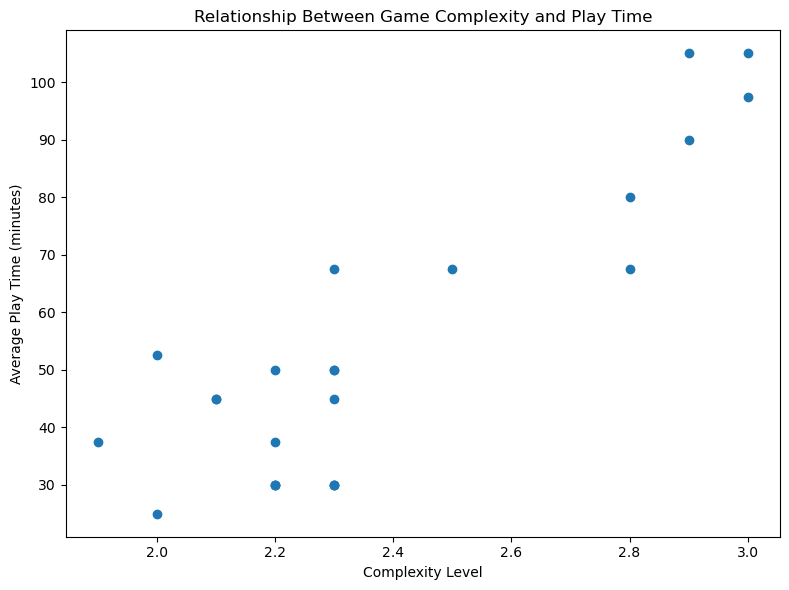

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(
    games_depth["ComplexityLevel"],
    games_depth["AvgPlayTime"]
)

plt.xlabel("Complexity Level")
plt.ylabel("Average Play Time (minutes)")
plt.title("Relationship Between Game Complexity and Play Time")

plt.tight_layout()
plt.show()
## כאן ניתן להסיק שככל שמשחק מורכב יותר כך זמן המשחק ארוך יותר

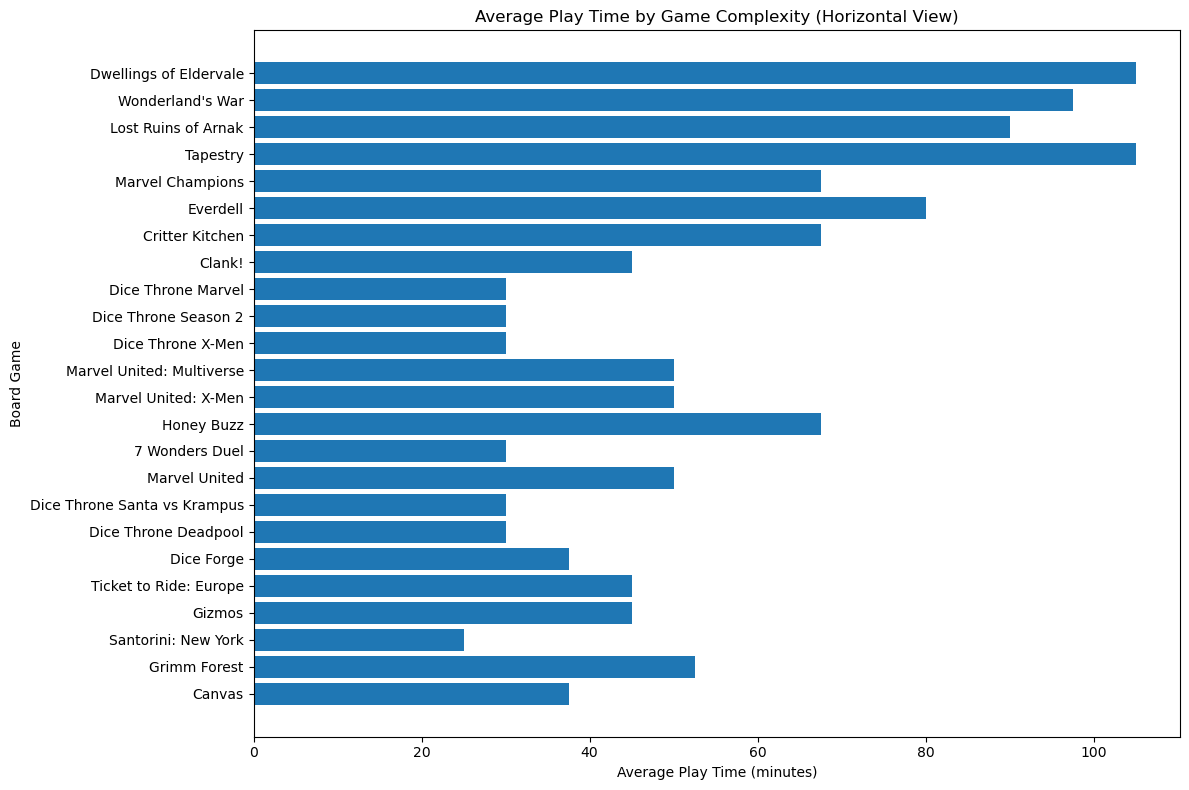

In [73]:
plt.figure(figsize=(12, 8))
plt.barh(games_sorted["BoardGameName"], games_sorted["AvgPlayTime"])

plt.xlabel("Average Play Time (minutes)")
plt.ylabel("Board Game")
plt.title("Average Play Time by Game Complexity (Horizontal View)")

plt.tight_layout()
plt.show()
## הצגתי כאן בדרך נוספת כדי שנוכל לראות איזה משחק מורכב ביותר (הגבוהה ביותר) לעומת משך המשחק
## ניתן להסיק כי ישנם משחקים קצרים יותר שרמת המורכבות שלהם היא לא נמוכה, לדוגמה honey buzz

In [78]:
year_price = (
    games_merged.groupby("ReleaseYear")["Origin Price"]
    .mean()
    .reset_index()
    .sort_values("ReleaseYear"))
##כאן אנסה לענות על השאלה האם בעבר משחקים היו זולים יותר מהיום

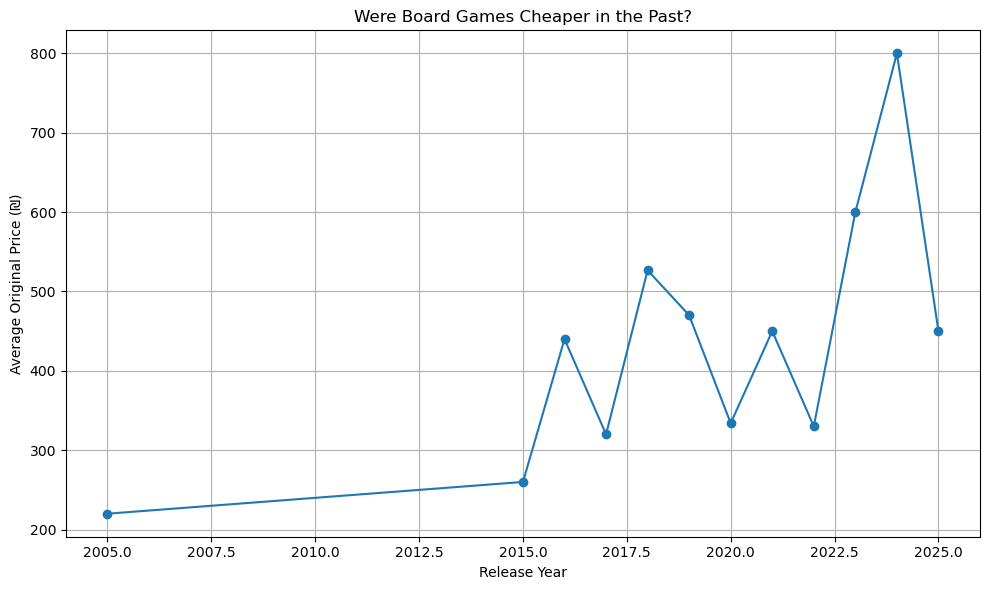

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(year_price["ReleaseYear"], year_price["Origin Price"], marker="o")

plt.xlabel("Release Year")
plt.ylabel("Average Original Price (₪)")
plt.title("Were Board Games Cheaper in the Past?")
plt.grid(True)
plt.tight_layout()
plt.show()

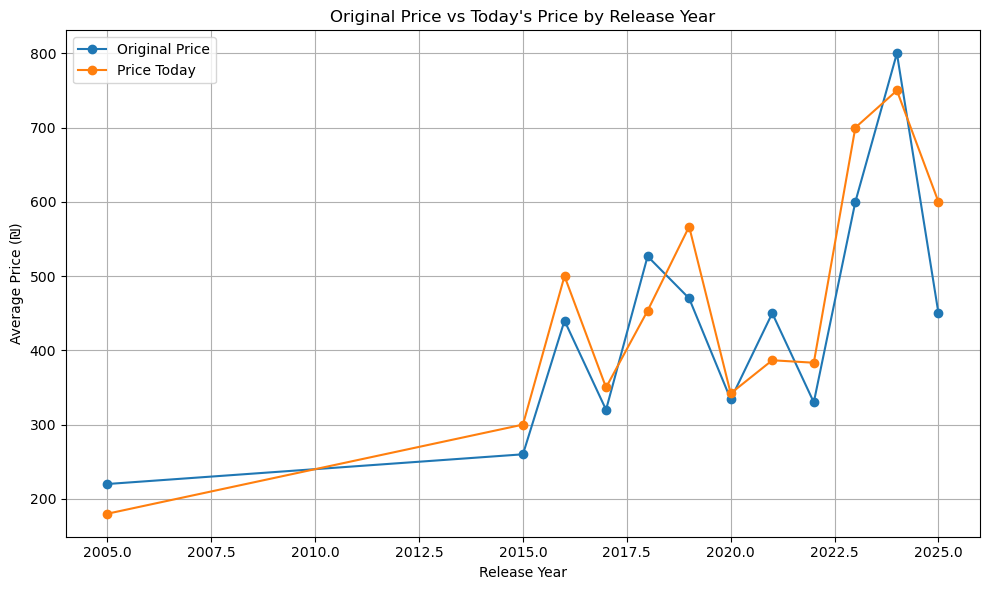

In [80]:
year_price_today = (
    games_merged.groupby("ReleaseYear")[["Origin Price", "Price Today"]]
    .mean()
    .reset_index()
    .sort_values("ReleaseYear")
)

plt.figure(figsize=(10, 6))

plt.plot(year_price_today["ReleaseYear"], year_price_today["Origin Price"], marker="o", label="Original Price")
plt.plot(year_price_today["ReleaseYear"], year_price_today["Price Today"], marker="o", label="Price Today")

plt.xlabel("Release Year")
plt.ylabel("Average Price (₪)")
plt.title("Original Price vs Today's Price by Release Year")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## כאן ניתן להשוות למחירים שנקנו לעומת המחירים היום. מסקנה - בעבר המחירים היו נמוכים יותר ואילו היום םה מאוד יקרים (וגם מעלים את שווי המכירה של יד 2)

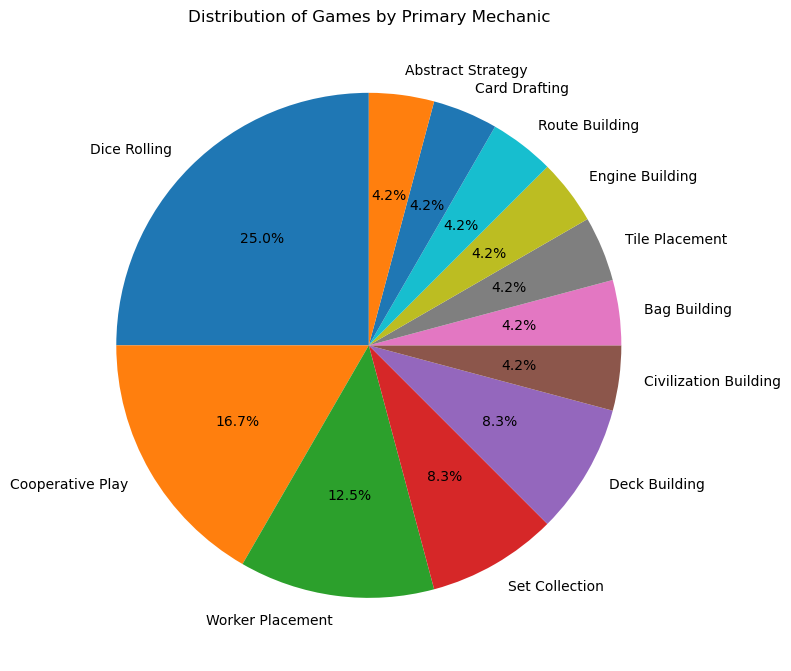

In [81]:
mechanic_counts = games_merged["PrimaryMechanic"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    mechanic_counts,
    labels=mechanic_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Games by Primary Mechanic")
plt.tight_layout()
plt.show()
##  בגרף זה שמתי את המכניקות שמופיעות הכי הרבה פעמים באוסף שלי אך מכיוון שכל משחק כולל הרבה גרסאות זה לא ודאי ולכן אצור גרף יותר רלוונטי שמתבסס על רמת המורכבות של המשחקים באוסף שלי (בהתבסס על אתר המשחקים BGG)

In [82]:
def complexity_group(x):
    if x < 2.3:
        return "Light"
    elif x < 3.0:
        return "Medium"
    else:
        return "Heavy"

games_merged["ComplexityGroup"] = games_merged["ComplexityLevel"].apply(complexity_group)
## פה הגדרתי את רמת המורכבות של המשחקים לפי אתר המשחקים BGG 

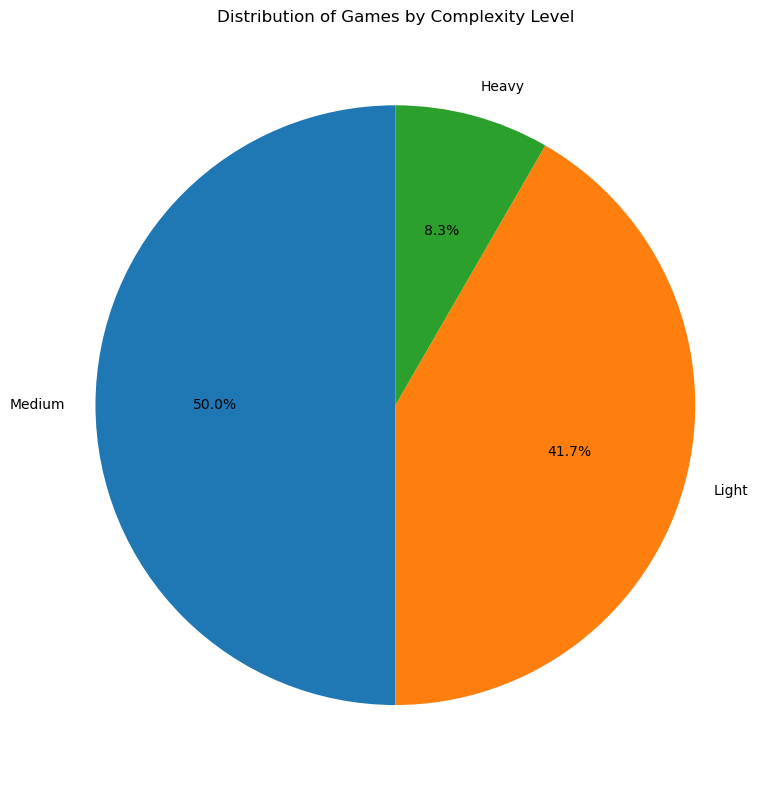

In [83]:
complexity_counts = games_merged["ComplexityGroup"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    complexity_counts,
    labels=complexity_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Games by Complexity Level")
plt.tight_layout()
plt.show()
## לפי גרף זה ניתן להסיק כי אני שהאוסף שלו כולל ברובו משחקים ברמה בינונית ומעט מאוד משחקים בעלי מורכבות גבוהה (ממש רציתי פאי צ'ארט)

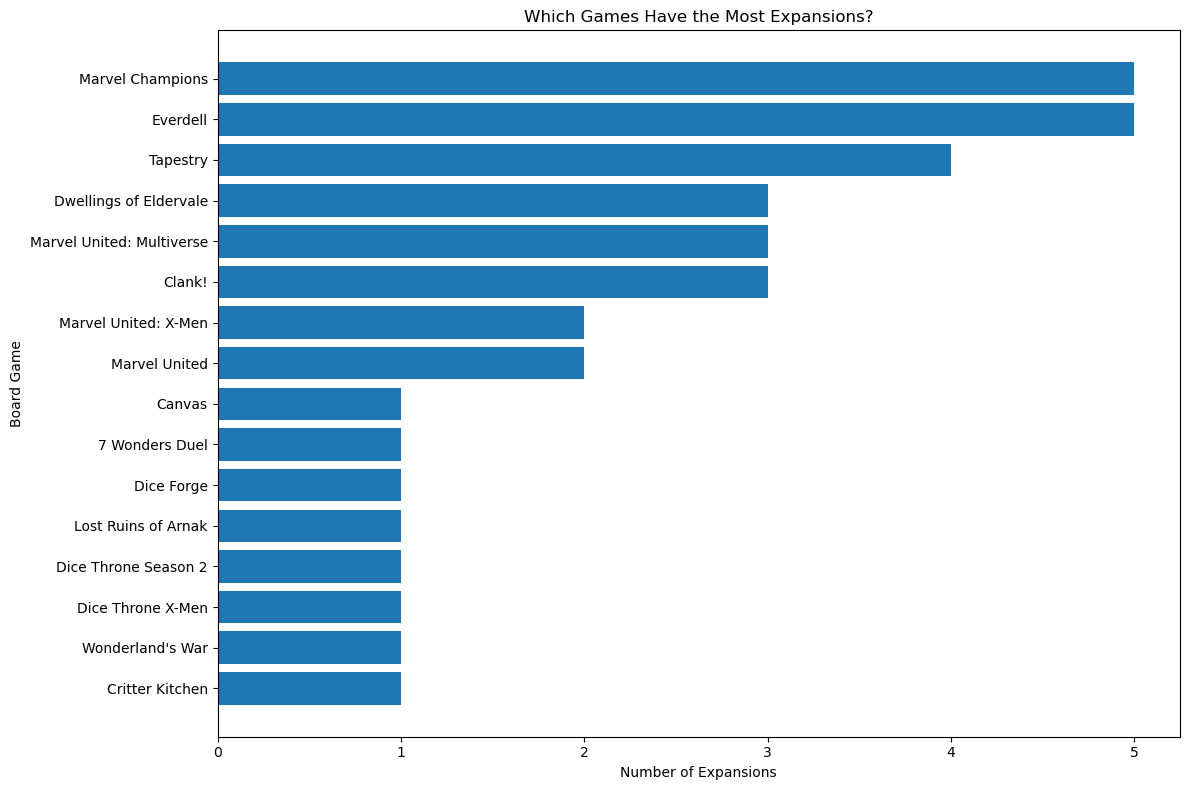

In [85]:
exp_sorted = expansions_per_game2.sort_values("NumExpansions", ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(exp_sorted["BoardGameName"], exp_sorted["NumExpansions"])

plt.xlabel("Number of Expansions")
plt.ylabel("Board Game")
plt.title("Which Games Have the Most Expansions?")
plt.tight_layout()
plt.show()
##בגרף זה הצגתי מהם המשחקים הכי "מושקעים" שלי שיש להם את מספר ההרחבות הרב ביותר וניתן להסיק בערך מה חלק המשחקים האהובים עליי - אם כי לא לכולם יש הרחבות כלל